# TableTalk Phase 2: five leagues

The Premier League, Bundesliga, La Liga, Serie A and Ligue 1, each added by config and data. Every league is fitted **separately**, with the Premier League's settings (365-day half-life, ridge sd 1, the `prior` promoted-team strategy, rating uncertainty in simulations); none were re-tuned per league.

- Results are on the **report seasons** (2018-19, 2021-22 to 2025-26); the COVID seasons are left out.
- Every league reproduces the **official final table of every season from 2010-11 to 2025-26** (`tests/test_official_tables.py`), which checks the data, team names, the season-by-season rules, points deductions and awarded results together.
- **Ratings must not be compared across leagues**: each is relative to its own league's average, and nothing puts two leagues on one scale (Phase 3).

Backtests are cached in `data/processed/p2_*.pkl` (delete to recompute; each league takes a few minutes). The Premier League and Bundesliga backtests were run just before their last tiebreaker became a simulated play-off match rather than a coin flip, which can only matter when clubs are level on every earlier criterion.

In [1]:
import warnings

import numpy as np
import pandas as pd

from tabletalk.config import load_competition
from tabletalk.data import load_context_matches, load_matches
from tabletalk.evaluation.backtest import match_backtest, paired_comparison, summarise_backtest
from tabletalk.evaluation.calibration import expected_calibration_error, match_calibration
from tabletalk.evaluation.market import MARKET, add_market_forecasts, gap_closed, load_market_odds
from tabletalk.evaluation.plots import plot_calibration
from tabletalk.evaluation.season_backtest import season_backtest, season_calibration_by_phase, summarise_zones
from tabletalk.paths import PROCESSED_DATA_DIR
from tabletalk.simulation import simulate_league

warnings.simplefilter('ignore', UserWarning)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 20)

LEAGUES = ['premier_league', 'bundesliga', 'la_liga', 'serie_a', 'ligue_1']

def cached(name, compute):
    path = PROCESSED_DATA_DIR / f'{name}.pkl'
    if path.exists():
        return pd.read_pickle(path)
    value = compute()
    pd.to_pickle(value, path)
    return value

def league_results(league):
    """Match, market and season backtests on the report seasons, cached."""
    config = load_competition(league)
    report = list(config.evaluation_split['report'])
    data = {}
    def matches_and_context():
        return load_matches(config, save=False), load_context_matches(config)
    def match():
        m, c = matches_and_context()
        return match_backtest(config, m, c, report)
    data['match'] = cached(f'p2_{league}_match_report', match)
    def market():
        base = data['match'].loc[data['match']['model'].isin(['prior', 'baseline'])]
        return add_market_forecasts(base, load_market_odds(config))
    data['market'] = cached(f'p2_{league}_benchmark_report', market)
    def season():
        m, c = matches_and_context()
        return season_backtest(config, m, c, report, n_simulations=5_000).zones
    data['zones'] = cached(f'p2_{league}_season_zones_report', season)
    return config, data

results = {league: league_results(league) for league in LEAGUES}
print('loaded:', ', '.join(results))

loaded: premier_league, bundesliga, la_liga, serie_a, ligue_1


## The five leagues side by side

In [2]:
rows = []
for league, (config, data) in results.items():
    s = summarise_backtest(data['market'])
    overall = s.loc[s['group'] == 'all matches'].set_index('model')['log_loss']
    base, model, market = overall['baseline'], overall['prior'], overall[MARKET]
    diff = paired_comparison(data['market'], 'prior', MARKET).iloc[0]
    tables = match_calibration(data['match'].loc[data['match']['model'] == 'prior'])
    zones = data['zones']
    from tabletalk.evaluation.calibration import calibration_table
    rows.append({
        'league': config.name,
        'matches': int((data['market']['model'] == MARKET).sum()),
        'log loss vs base rates (%)': round(100 * (model / base - 1), 1),
        'gap to market closed (%)': round(100 * (base - model) / (base - market)),
        'model minus market': f"{diff['diff']:.3f} ± {diff['ci95']:.3f}",
        'calibration gap H/D/A (pts)': ' / '.join(f"{100 * expected_calibration_error(tables[o]):.1f}" for o in ('home', 'draw', 'away')),
        'season calibration gap (pts)': round(100 * expected_calibration_error(calibration_table(zones['p_model'], zones['outcome'])), 1),
    })
pd.DataFrame(rows).set_index('league')

,matches,log loss vs base rates (%),gap to market closed (%),model minus market,calibration gap H/D/A (pts),season calibration gap (pts)
league,,,,,,
Premier League,2280,-9.4,83,0.020 ± 0.007,3.0 / 1.2 / 1.9,1.3
Bundesliga,1835,-7.5,81,0.019 ± 0.007,3.2 / 1.2 / 2.4,1.2
La Liga,2280,-7.6,83,0.016 ± 0.007,3.0 / 2.1 / 3.0,1.0
Serie A,2280,-9.6,85,0.018 ± 0.007,1.9 / 2.7 / 3.1,1.6
Ligue 1,2058,-6.4,77,0.020 ± 0.007,1.2 / 0.7 / 2.1,1.1


Across the five leagues the model closes roughly 77-85% of the gap between knowing nothing (the league's base rates) and the bookmakers' closing odds, and trails the market by about 0.02 in log loss. Part of that gap is information the model never sees: line-ups, injuries, managerial changes.

## Premier League

The reference league. Full detail, including how the settings were chosen, is in `premier_league_results.ipynb`.

In [3]:
config, data = results['premier_league']
changes = config.raw.get('rule_changes') or []
rules = [{'from': 'start of data', 'clubs': config.league.n_teams,
          'relegation': config.zone('relegation').positions,
          'tiebreakers': ', '.join(config.tiebreakers)}]
for change in changes:
    season = change.get('from_season') or ', '.join(change['seasons'])
    version = config.for_season(change.get('from_season') or change['seasons'][0])
    rules.append({'from': season, 'clubs': version.league.n_teams,
                  'relegation': version.zone('relegation').positions,
                  'tiebreakers': ', '.join(version.tiebreakers)})
pd.DataFrame(rules)

,from,clubs,relegation,tiebreakers
0,start of data,20,"(18, 19, 20)","goal_difference, goals_scored, head_to_head_po..."


In [4]:
current = simulate_league(config, load_matches(config, save=False), load_context_matches(config))
zone_ids = [zone.id for zone in config.for_season(config.current_season).zones]
summary = current.summary()
(100 * summary[zone_ids]).round(1).assign(expected_points=summary['expected_points'].round(1)).head(20)

,title,top_four,top_five,top_half,relegation,expected_points
team,,,,,,
Manchester City,58.1,98.0,99.1,100.0,0.0,82.2
Arsenal,34.6,95.5,97.5,99.9,0.0,78.6
Liverpool,4.1,62.5,73.8,96.2,0.0,66.7
Brighton & Hove Albion,1.3,36.9,50.1,87.8,0.3,61.1
Brentford,0.5,21.0,32.9,77.4,0.8,57.5
Chelsea,0.3,18.2,28.4,72.9,1.0,56.6
Newcastle United,0.4,17.6,28.0,72.1,1.2,56.4
Manchester United,0.2,12.7,20.5,63.4,2.1,54.1
Leeds United,0.2,9.9,16.5,54.4,4.0,52.4


In [5]:
print('market comparison per season (log loss; share of the baseline-to-market gap closed)')
gap_closed(data['market'], 'prior').round(3)

market comparison per season (log loss; share of the baseline-to-market gap closed)


,season,n,baseline,prior,market,model_minus_market,gap_closed_pct
0,2018-19,380,1.046,0.898,0.891,0.007,95.225
1,2021-22,380,1.071,0.950,0.937,0.013,90.474
2,2022-23,380,1.050,0.998,0.962,0.036,58.722
3,2023-24,380,1.055,0.924,0.900,0.024,84.304
4,2024-25,380,1.082,0.988,0.966,0.022,81.373
5,2025-26,380,1.082,1.030,1.014,0.017,75.872


In [6]:
z = summarise_zones(data['zones'], 5_000)
order = z['checkpoint'].unique()
print('Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)')
z.pivot(index='checkpoint', columns='zone', values='skill_vs_persistence_pct').loc[order].round(1)

Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)


zone,relegation,title,top_five,top_four,top_half
checkpoint,,,,,
pre-season,22.8,35.0,55.0,46.0,42.6
25% played,30.9,76.2,52.8,54.5,32.5
50% played,34.9,67.5,58.6,29.2,14.1
75% played,22.5,69.0,58.6,44.3,44.3


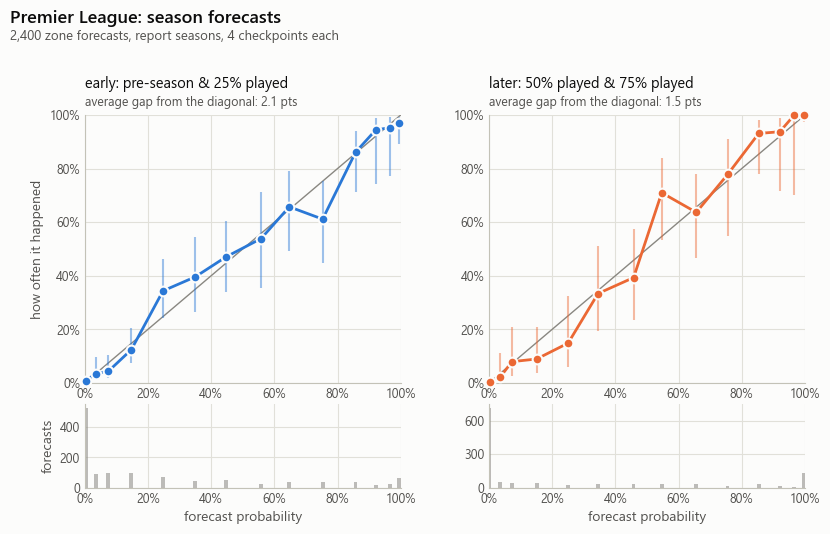

In [7]:
plot_calibration(
    season_calibration_by_phase(data['zones']),
    title='Premier League: season forecasts',
    subtitle=f"{len(data['zones']):,} zone forecasts, report seasons, 4 checkpoints each",
);

## Bundesliga

18 clubs; 16th goes into a relegation play-off. Tiebreakers after goals scored: the aggregate score of the two meetings, head-to-head away goals, all away goals, then a play-off match (simulated).

In [8]:
config, data = results['bundesliga']
changes = config.raw.get('rule_changes') or []
rules = [{'from': 'start of data', 'clubs': config.league.n_teams,
          'relegation': config.zone('relegation').positions,
          'tiebreakers': ', '.join(config.tiebreakers)}]
for change in changes:
    season = change.get('from_season') or ', '.join(change['seasons'])
    version = config.for_season(change.get('from_season') or change['seasons'][0])
    rules.append({'from': season, 'clubs': version.league.n_teams,
                  'relegation': version.zone('relegation').positions,
                  'tiebreakers': ', '.join(version.tiebreakers)})
pd.DataFrame(rules)

,from,clubs,relegation,tiebreakers
0,start of data,18,"(17, 18)","goal_difference, goals_scored, head_to_head_go..."


In [9]:
current = simulate_league(config, load_matches(config, save=False), load_context_matches(config))
zone_ids = [zone.id for zone in config.for_season(config.current_season).zones]
summary = current.summary()
(100 * summary[zone_ids]).round(1).assign(expected_points=summary['expected_points'].round(1)).head(20)

,title,top_four,top_five,top_half,relegation_playoff,relegation,expected_points
team,,,,,,,
Bayern Munich,84.0,99.9,100.0,100.0,0.0,0.0,81.7
Borussia Dortmund,12.2,92.6,96.5,99.8,0.0,0.0,70.0
Bayer Leverkusen,2.7,72.0,83.2,98.0,0.0,0.0,62.4
RB Leipzig,0.6,44.9,61.4,91.7,0.1,0.0,56.8
VfB Stuttgart,0.2,29.5,45.9,85.4,0.4,0.4,53.8
SC Freiburg,0.1,19.4,32.2,77.3,0.8,0.4,51.2
Mainz 05,0.0,9.2,17.3,60.0,1.7,1.7,47.1
Eintracht Frankfurt,0.0,8.6,16.6,58.6,2.2,1.9,47.0
SV Elversberg,0.1,9.1,15.0,44.1,5.6,7.9,43.7


In [10]:
print('market comparison per season (log loss; share of the baseline-to-market gap closed)')
gap_closed(data['market'], 'prior').round(3)

market comparison per season (log loss; share of the baseline-to-market gap closed)


,season,n,baseline,prior,market,model_minus_market,gap_closed_pct
0,2018-19,305,1.066,0.983,0.967,0.016,83.890
1,2021-22,306,1.058,0.997,0.980,0.016,79.342
2,2022-23,306,1.057,0.999,0.996,0.003,94.737
3,2023-24,306,1.076,0.978,0.944,0.034,73.923
4,2024-25,306,1.093,1.016,0.988,0.028,73.277
5,2025-26,306,1.071,0.968,0.950,0.018,85.469


In [11]:
z = summarise_zones(data['zones'], 5_000)
order = z['checkpoint'].unique()
print('Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)')
z.pivot(index='checkpoint', columns='zone', values='skill_vs_persistence_pct').loc[order].round(1)

Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)


zone,relegation,relegation_playoff,title,top_five,top_four,top_half
checkpoint,,,,,,
pre-season,48.0,53.1,46.1,50.1,55.5,41.3
25% played,45.9,31.9,60.2,35.0,56.6,39.6
50% played,NaN,48.4,20.7,37.6,19.0,23.3
75% played,58.3,55.9,88.3,32.4,51.3,23.0


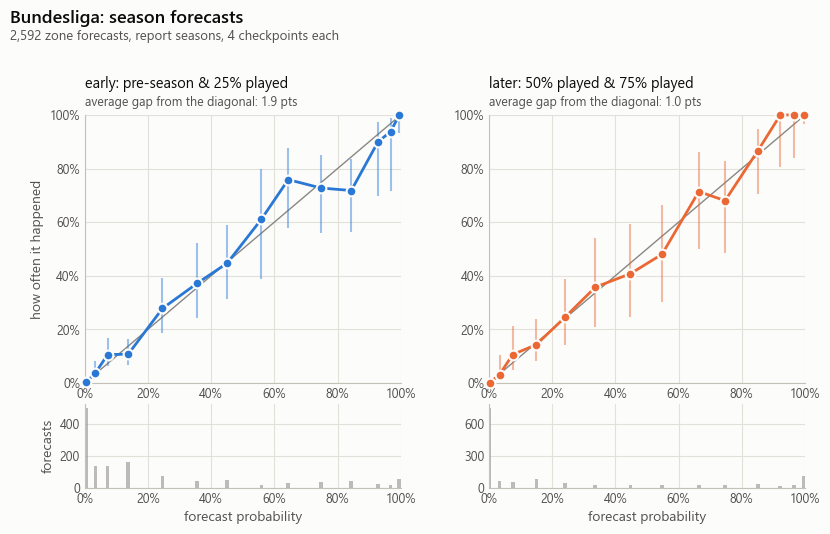

In [12]:
plot_calibration(
    season_calibration_by_phase(data['zones']),
    title='Bundesliga: season forecasts',
    subtitle=f"{len(data['zones']):,} zone forecasts, report seasons, 4 checkpoints each",
);

## La Liga

Head-to-head comes first: for clubs level on points, their meetings count before overall goal difference, as a mini-league when three or more are level.

In [13]:
config, data = results['la_liga']
changes = config.raw.get('rule_changes') or []
rules = [{'from': 'start of data', 'clubs': config.league.n_teams,
          'relegation': config.zone('relegation').positions,
          'tiebreakers': ', '.join(config.tiebreakers)}]
for change in changes:
    season = change.get('from_season') or ', '.join(change['seasons'])
    version = config.for_season(change.get('from_season') or change['seasons'][0])
    rules.append({'from': season, 'clubs': version.league.n_teams,
                  'relegation': version.zone('relegation').positions,
                  'tiebreakers': ', '.join(version.tiebreakers)})
pd.DataFrame(rules)

,from,clubs,relegation,tiebreakers
0,start of data,20,"(18, 19, 20)","head_to_head_points, head_to_head_goal_differe..."


In [14]:
current = simulate_league(config, load_matches(config, save=False), load_context_matches(config))
zone_ids = [zone.id for zone in config.for_season(config.current_season).zones]
summary = current.summary()
(100 * summary[zone_ids]).round(1).assign(expected_points=summary['expected_points'].round(1)).head(20)

,title,top_four,top_five,top_half,relegation,expected_points
team,,,,,,
Barcelona,81.2,99.9,100.0,100.0,0.0,91.0
Real Madrid,14.6,97.2,98.9,100.0,0.0,80.2
Atlético Madrid,3.8,87.3,94.1,99.7,0.0,73.8
Real Betis,0.3,51.2,69.1,96.6,0.0,65.1
Villarreal,0.1,24.1,43.6,87.8,0.4,59.7
Athletic Bilbao,0.0,10.9,21.9,71.1,2.0,54.5
Real Sociedad,0.0,7.5,17.0,67.4,2.2,53.6
Sevilla,0.0,6.4,14.8,64.0,2.6,52.9
Celta Vigo,0.0,3.1,8.2,48.7,6.1,49.4


In [15]:
print('market comparison per season (log loss; share of the baseline-to-market gap closed)')
gap_closed(data['market'], 'prior').round(3)

market comparison per season (log loss; share of the baseline-to-market gap closed)


,season,n,baseline,prior,market,model_minus_market,gap_closed_pct
0,2018-19,380,1.081,1.019,1.002,0.017,78.675
1,2021-22,380,1.082,1.005,0.989,0.016,82.467
2,2022-23,380,1.052,0.993,0.976,0.017,77.491
3,2023-24,380,1.077,0.959,0.951,0.008,93.796
4,2024-25,380,1.071,0.975,0.946,0.029,76.910
5,2025-26,380,1.048,0.976,0.965,0.011,86.333


In [16]:
z = summarise_zones(data['zones'], 5_000)
order = z['checkpoint'].unique()
print('Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)')
z.pivot(index='checkpoint', columns='zone', values='skill_vs_persistence_pct').loc[order].round(1)

Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)


zone,relegation,title,top_five,top_four,top_half
checkpoint,,,,,
pre-season,42.0,52.7,44.3,32.1,37.2
25% played,38.2,50.8,57.3,78.2,27.8
50% played,48.2,27.2,44.9,65.6,35.5
75% played,28.5,NaN,57.4,55.0,29.0


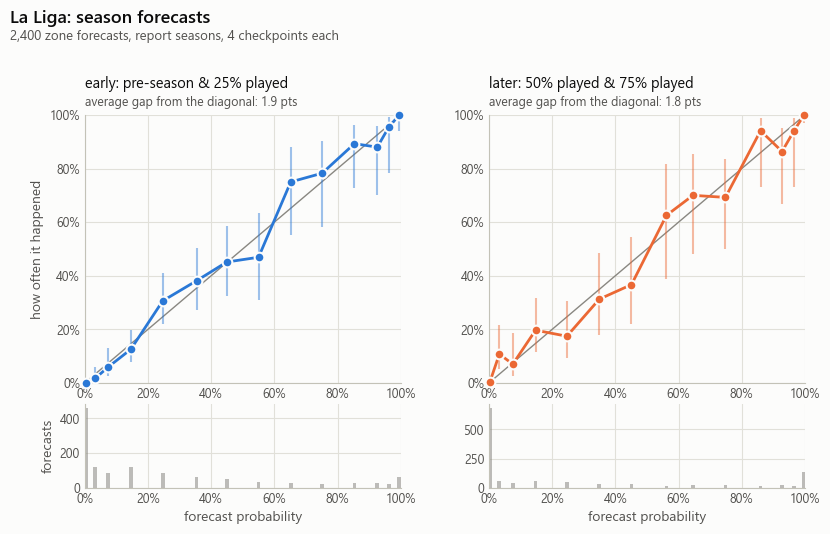

In [17]:
plot_calibration(
    season_calibration_by_phase(data['zones']),
    title='La Liga: season forecasts',
    subtitle=f"{len(data['zones']):,} zone forecasts, report seasons, 4 checkpoints each",
);

## Serie A

Head-to-head first (the *classifica avulsa*). From 2022-23 a tie for the title or for 17th v 18th is settled by a play-off, simulated in the format of each season (one match, or two legs from 2023-24).

In [18]:
config, data = results['serie_a']
changes = config.raw.get('rule_changes') or []
rules = [{'from': 'start of data', 'clubs': config.league.n_teams,
          'relegation': config.zone('relegation').positions,
          'tiebreakers': ', '.join(config.tiebreakers)}]
for change in changes:
    season = change.get('from_season') or ', '.join(change['seasons'])
    version = config.for_season(change.get('from_season') or change['seasons'][0])
    rules.append({'from': season, 'clubs': version.league.n_teams,
                  'relegation': version.zone('relegation').positions,
                  'tiebreakers': ', '.join(version.tiebreakers)})
pd.DataFrame(rules)

,from,clubs,relegation,tiebreakers
0,start of data,20,"(18, 19, 20)","head_to_head_points, head_to_head_goal_differe..."
1,2022-23,20,"(18, 19, 20)","head_to_head_points, head_to_head_goal_differe..."
2,2023-24,20,"(18, 19, 20)","head_to_head_points, head_to_head_goal_differe..."


In [19]:
current = simulate_league(config, load_matches(config, save=False), load_context_matches(config))
zone_ids = [zone.id for zone in config.for_season(config.current_season).zones]
summary = current.summary()
(100 * summary[zone_ids]).round(1).assign(expected_points=summary['expected_points'].round(1)).head(20)

,title,top_four,top_five,top_half,relegation,expected_points
team,,,,,,
Inter Milan,63.1,95.8,97.8,100.0,0.0,83.4
Roma,17.7,77.0,86.2,99.7,0.0,75.1
Juventus,5.1,49.6,63.4,97.8,0.0,68.6
Como,5.1,46.7,60.3,96.9,0.0,68.0
AC Milan,3.5,41.1,55.8,96.2,0.0,67.0
Napoli,2.6,37.7,52.9,96.0,0.0,66.3
Atalanta,1.4,24.1,35.8,91.4,0.1,62.9
Lazio,1.4,21.0,32.7,90.5,0.1,62.3
Cagliari,0.0,2.1,4.0,44.3,2.8,50.1


In [20]:
print('market comparison per season (log loss; share of the baseline-to-market gap closed)')
gap_closed(data['market'], 'prior').round(3)

market comparison per season (log loss; share of the baseline-to-market gap closed)


,season,n,baseline,prior,market,model_minus_market,gap_closed_pct
0,2018-19,380,1.078,0.970,0.944,0.026,80.596
1,2021-22,380,1.092,0.981,0.973,0.008,93.009
2,2022-23,380,1.080,0.991,0.975,0.016,84.686
3,2023-24,380,1.087,0.986,0.964,0.023,81.624
4,2024-25,380,1.092,0.970,0.951,0.018,87.040
5,2025-26,380,1.091,0.994,0.978,0.016,85.412


In [21]:
z = summarise_zones(data['zones'], 5_000)
order = z['checkpoint'].unique()
print('Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)')
z.pivot(index='checkpoint', columns='zone', values='skill_vs_persistence_pct').loc[order].round(1)

Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)


zone,relegation,title,top_five,top_four,top_half
checkpoint,,,,,
pre-season,38.4,55.4,40.2,38.9,6.8
25% played,20.9,52.0,46.8,43.3,56.1
50% played,39.1,-45.0,28.4,50.4,37.8
75% played,13.9,20.0,41.1,36.6,32.6


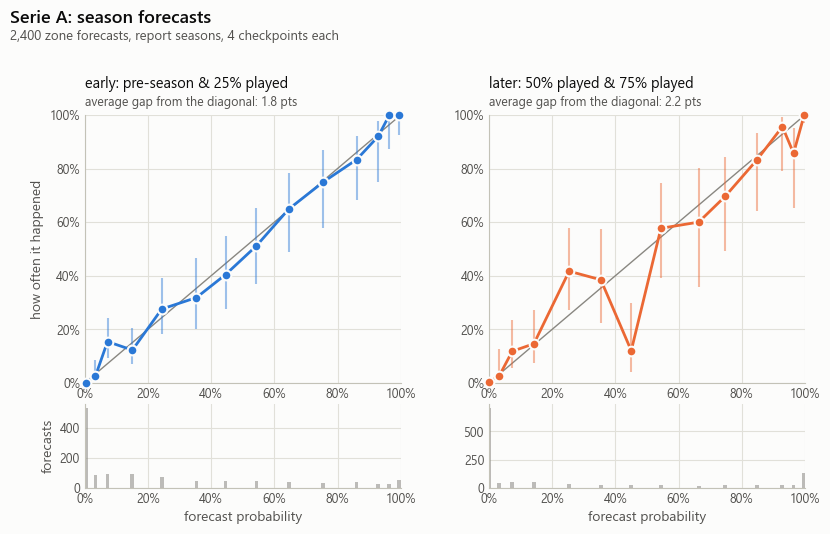

In [22]:
plot_calibration(
    season_calibration_by_phase(data['zones']),
    title='Serie A: season forecasts',
    subtitle=f"{len(data['zones']):,} zone forecasts, report seasons, 4 checkpoints each",
);

## Ligue 1

The format changed five times: 20 clubs to 18 in 2023-24, relegation places and the play-off place moved, 2019-20 was stopped early and ranked on points per match, and the tiebreakers changed in 2025-26.

In [23]:
config, data = results['ligue_1']
changes = config.raw.get('rule_changes') or []
rules = [{'from': 'start of data', 'clubs': config.league.n_teams,
          'relegation': config.zone('relegation').positions,
          'tiebreakers': ', '.join(config.tiebreakers)}]
for change in changes:
    season = change.get('from_season') or ', '.join(change['seasons'])
    version = config.for_season(change.get('from_season') or change['seasons'][0])
    rules.append({'from': season, 'clubs': version.league.n_teams,
                  'relegation': version.zone('relegation').positions,
                  'tiebreakers': ', '.join(version.tiebreakers)})
pd.DataFrame(rules)

,from,clubs,relegation,tiebreakers
0,start of data,20,"(18, 19, 20)","goal_difference, head_to_head_points, head_to_..."
1,2016-17,20,"(19, 20)","goal_difference, head_to_head_points, head_to_..."
2,2019-20,20,"(19, 20)","head_to_head_points, head_to_head_goal_differe..."
3,2022-23,20,"(17, 18, 19, 20)","goal_difference, head_to_head_points, head_to_..."
4,2023-24,18,"(17, 18)","goal_difference, head_to_head_points, head_to_..."
5,2025-26,18,"(17, 18)","goal_difference, head_to_head_points, head_to_..."


In [24]:
current = simulate_league(config, load_matches(config, save=False), load_context_matches(config))
zone_ids = [zone.id for zone in config.for_season(config.current_season).zones]
summary = current.summary()
(100 * summary[zone_ids]).round(1).assign(expected_points=summary['expected_points'].round(1)).head(20)

,title,top_four,top_five,top_half,relegation_playoff,relegation,expected_points
team,,,,,,,
Paris Saint-Germain,61.2,95.2,97.6,99.9,0.0,0.0,70.7
Monaco,14.8,69.3,79.6,96.9,0.0,0.0,62.3
Lyon,7.6,51.9,64.4,93.3,0.1,0.0,58.5
Lille,7.1,49.9,61.8,92.2,0.1,0.0,58.2
Rennes,2.1,28.6,39.9,79.9,0.4,0.2,53.8
Paris FC,3.2,29.5,40.2,78.0,0.6,0.4,53.5
Lens,1.8,25.4,36.2,78.4,0.5,0.3,52.6
Marseille,1.0,21.9,32.5,75.4,0.9,0.3,51.8
Strasbourg,0.9,15.7,24.7,67.5,0.9,0.5,50.3


In [25]:
print('market comparison per season (log loss; share of the baseline-to-market gap closed)')
gap_closed(data['market'], 'prior').round(3)

market comparison per season (log loss; share of the baseline-to-market gap closed)


,season,n,baseline,prior,market,model_minus_market,gap_closed_pct
0,2018-19,380,1.079,1.040,1.003,0.038,50.632
1,2021-22,380,1.080,1.010,1.001,0.010,87.890
2,2022-23,380,1.077,0.984,0.969,0.015,85.993
3,2023-24,306,1.094,1.033,1.014,0.019,76.136
4,2024-25,306,1.057,0.972,0.955,0.017,83.207
5,2025-26,306,1.063,0.998,0.977,0.020,76.062


In [26]:
z = summarise_zones(data['zones'], 5_000)
order = z['checkpoint'].unique()
print('Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)')
z.pivot(index='checkpoint', columns='zone', values='skill_vs_persistence_pct').loc[order].round(1)

Brier skill vs "the table as it stands" (%; NaN = that baseline was exactly right)


zone,relegation,relegation_playoff,title,top_five,top_four,top_half
checkpoint,,,,,,
pre-season,43.3,51.8,67.4,33.6,43.9,31.6
25% played,56.1,52.2,91.1,51.8,42.1,47.6
50% played,51.1,42.7,95.8,8.1,16.8,13.1
75% played,50.6,45.3,NaN,8.4,32.1,24.1


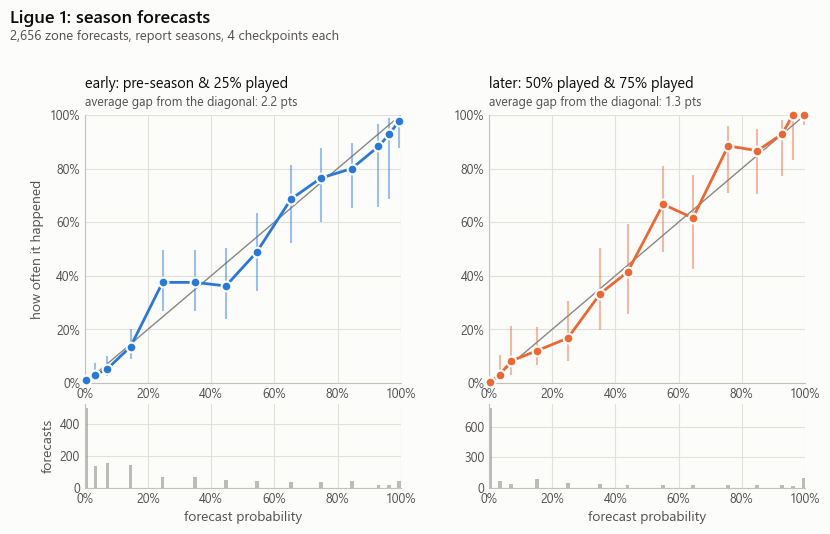

In [27]:
plot_calibration(
    season_calibration_by_phase(data['zones']),
    title='Ligue 1: season forecasts',
    subtitle=f"{len(data['zones']):,} zone forecasts, report seasons, 4 checkpoints each",
);

## Known limitations, by league

- **All:** Premier League settings everywhere; team ratings are not comparable across leagues; fair-play and card-count tiebreakers are not modelled (coin flip); play-offs use best-estimate ratings.
- **Bundesliga:** the promoted-team prior rests on few clubs early on (usually two promoted); the head-to-head tiebreakers before 2019-20 are unconfirmed by a rule text (untested by history, as no real tie reached them).
- **La Liga:** three-way ties are resolved UEFA-style; the other reading of the 2025-26 text never changed a real table.
- **Serie A:** the 2022-23 ruling and those before 2019-20 were not found; from 2026-27 no play-off is held if a club is in a European final (not modelled).
- **Ligue 1:** the LFP's regulations before 2025 and its 2019-20 decision were not found (the rules used reproduce every official table); the relegation play-off place is barely predictable.